# Laboratorio 4 — Inciso 6: Correlación de NDVI y NDWI con la cianobacteria

Se calcula la correlación de Pearson entre el índice de cianobacteria (`clorofila`) y cada uno de NDVI y NDWI, usando todos los píxeles de agua de las 11 fechas de cada lago, y se interpreta el signo y la fuerza de la relación.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.descarga import ruta_raster
from src.raster import abrir


## Píxeles de agua agrupados por lago

Se juntan (pool) todos los píxeles de agua de las 11 fechas de cada lago en un solo vector por índice, para tener suficiente cantidad de datos y calcular una correlación representativa del lago completo en el período estudiado (no solo de una fecha).


In [3]:
def pixeles_agrupados(lago):
    clorofila_todo, ndvi_todo, ndwi_todo = [], [], []
    for fecha in FECHAS_OFICIALES[lago]:
        bandas = abrir(ruta_raster(lago, fecha))
        agua = bandas["agua"] > 0
        clorofila_todo.append(bandas["clorofila"][agua])
        ndvi_todo.append(bandas["ndvi"][agua])
        ndwi_todo.append(bandas["ndwi"][agua])
    return {
        "clorofila": np.concatenate(clorofila_todo),
        "ndvi": np.concatenate(ndvi_todo),
        "ndwi": np.concatenate(ndwi_todo),
    }

pooled = {lago: pixeles_agrupados(lago) for lago in LAGOS}
{lago: len(v["clorofila"]) for lago, v in pooled.items()}


{'atitlan': 3377514, 'amatitlan': 402526}

## Coeficiente de correlación de Pearson

Se calcula `r` (fuerza y signo de la relación lineal) y el valor `p` (significancia estadística) entre `clorofila` y cada uno de `ndvi`/`ndwi`, por separado para cada lago.


In [4]:
filas = []
for lago in LAGOS:
    for indice in ["ndvi", "ndwi"]:
        r, p = pearsonr(pooled[lago]["clorofila"], pooled[lago][indice])
        filas.append({"lago": lago, "indice": indice, "r_pearson": r, "p_valor": p})

correlaciones = pd.DataFrame(filas)
correlaciones.to_csv(RUTA_DATA_PROCESSED / "correlaciones_indices.csv", index=False)
correlaciones


,lago,indice,r_pearson,p_valor
0,atitlan,ndvi,0.468124,0.0
1,atitlan,ndwi,-0.450437,0.0
2,amatitlan,ndvi,0.753630,0.0
3,amatitlan,ndwi,-0.615907,0.0


## Visualización: densidad de puntos (hexbin)

Con millones de píxeles, un scatter plot normal se satura. Se usa `hexbin`, que agrupa los puntos en hexágonos y colorea según cuántos píxeles caen en cada uno, mostrando dónde se concentra realmente la relación.


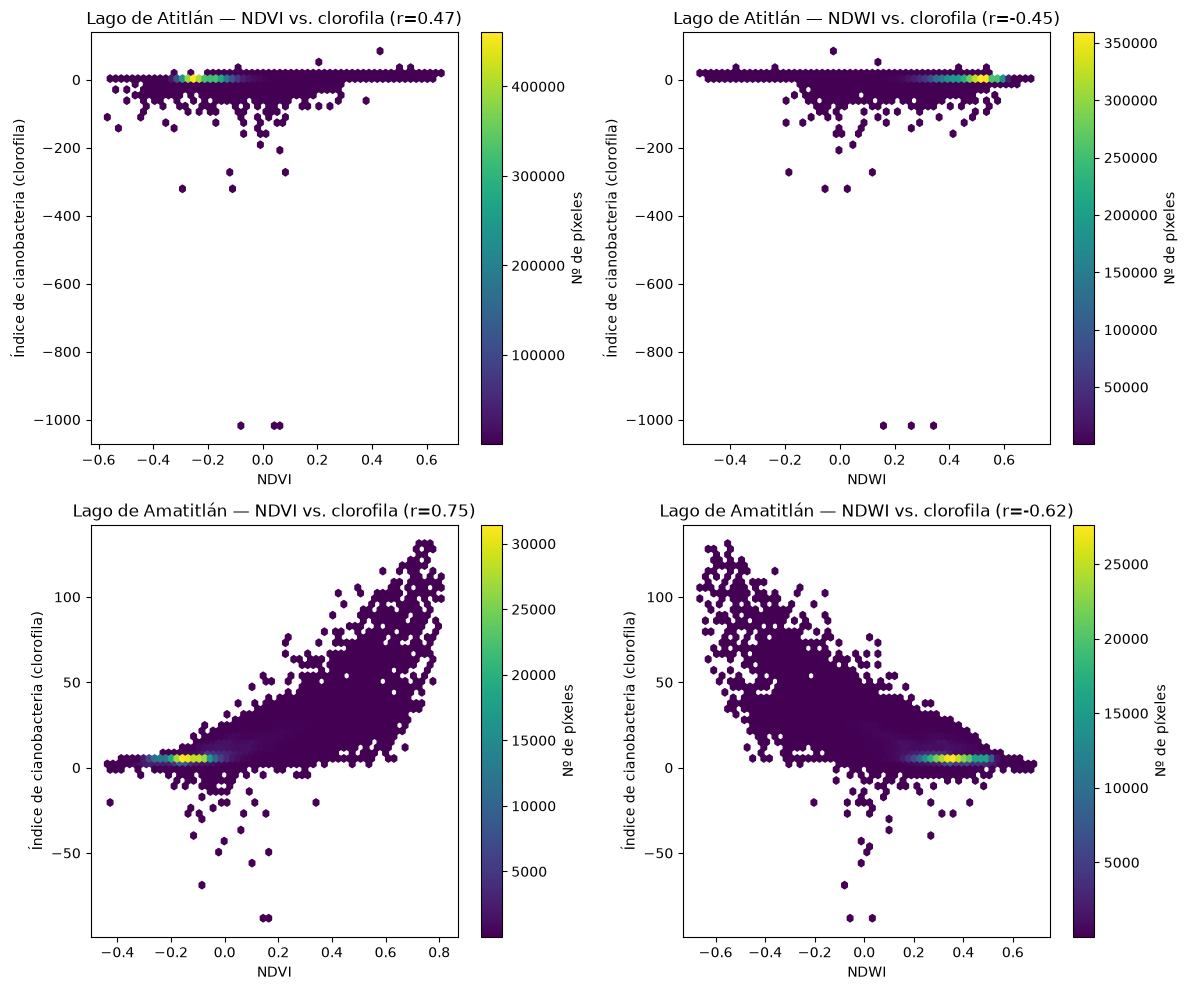

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for fila, lago in enumerate(LAGOS):
    for col, indice in enumerate(["ndvi", "ndwi"]):
        ax = axes[fila, col]
        hb = ax.hexbin(pooled[lago][indice], pooled[lago]["clorofila"], gridsize=60, cmap="viridis", mincnt=1)
        r = correlaciones.loc[(correlaciones["lago"] == lago) & (correlaciones["indice"] == indice), "r_pearson"].iloc[0]
        ax.set_title(f"{LAGOS[lago]['nombre']} — {indice.upper()} vs. clorofila (r={r:.2f})")
        ax.set_xlabel(indice.upper())
        ax.set_ylabel("Índice de cianobacteria (clorofila)")
        fig.colorbar(hb, ax=ax, label="Nº de píxeles")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "correlacion_indices.png", dpi=150)
plt.show()


## 6.1 Interpretación

**Signo y fuerza:** en ambos lagos el patrón es el mismo — NDVI correlaciona **positivamente** con la cianobacteria (Atitlán r=0.47, Amatitlán r=0.75) y NDWI correlaciona **negativamente** (Atitlán r=-0.45, Amatitlán r=-0.62). Es decir, a mayor cianobacteria el agua se ve espectralmente menos como "agua limpia" (NDWI baja) y más como "vegetación" (NDVI sube), coherente con que las floraciones forman natas/biomasa superficial que refleja el infrarrojo cercano de forma similar a la vegetación y altera la firma espectral típica de agua abierta.

**Amatitlán tiene la relación más fuerte y más limpia** (r=0.75 y -0.62): la nube de puntos es claramente triangular y sin outliers extremos, consistente con un lago donde la señal de cianobacteria domina y se relaciona de forma predecible con ambos índices.

**En Atitlán la correlación moderada está distorsionada por outliers de borde**: unos pocos píxeles llegan a clorofila ≈ -1000, el mismo problema de píxeles mixtos ya señalado en el inciso 3 (denominador del NDCI cercano a cero en la orilla). Sin esos outliers, la nube de Atitlán es en realidad una banda casi plana alrededor de clorofila ≈ 0 en casi todo el rango de NDVI/NDWI: la relación real dentro del lago es débil, consistente con que Atitlán está mucho menos eutrofizado y su señal de cianobacteria es baja y ruidosa frente a la de Amatitlán.

**Significado ambiental:** NDVI y NDWI no reemplazan al índice de cianobacteria, pero funcionan como alerta indirecta — un NDVI anormalmente alto o un NDWI anormalmente bajo dentro de un cuerpo de agua es indicio visual rápido de posible floración, mucho más confiable en Amatitlán que en Atitlán.
